📦 Chargement du modèle : C:\Users\MSI\Desktop\COVID19-XRay-Classification\models\simple_cnn_model.h5


Model: "functional_393"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Found 8464 images belonging to 4 classes.


C:\Users\MSI\anaconda3\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


265/265 ━━━━━━━━━━━━━━━━━━━━ 31s 118ms/step

📊 RAPPORT DE CLASSIFICATION

                 precision    recall  f1-score   support

          COVID      0.856     0.775     0.813      1446
   Lung_Opacity      0.803     0.864     0.832      2404
         NORMAL      0.890     0.881     0.886      4076
Viral Pneumonia      0.900     0.885     0.892       538

       accuracy                          0.859      8464
      macro avg      0.862     0.851     0.856      8464
   weighted avg      0.860     0.859     0.859      8464



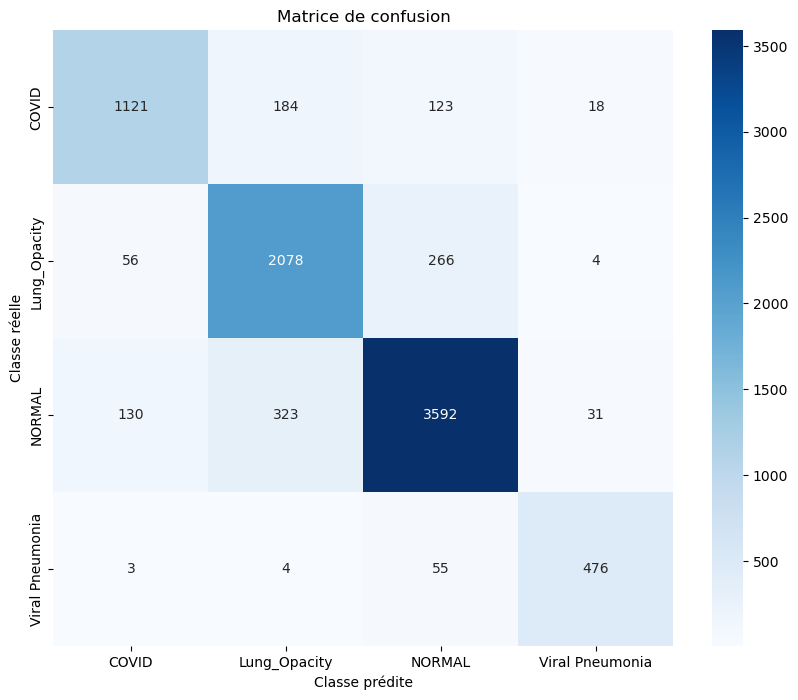

✅ Métriques sauvegardées : C:\Users\MSI\Desktop\COVID19-XRay-Classification\results\metrics.json
🧠 Dernière couche Conv2D : conv2d_2
🔥 Génération Grad-CAM...


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m2352028972224\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 128, 128, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

In [70]:
# =========================================================
# IMPORTS
# =========================================================
import os
import json
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# =========================================================
# CONFIGURATION
# =========================================================
DATA_DIR = r"C:\Users\MSI\Desktop\COVID19-XRay-Classification\data"
MODEL_PATH = r"C:\Users\MSI\Desktop\COVID19-XRay-Classification\models\simple_cnn_model.h5"
RESULTS_DIR = r"C:\Users\MSI\Desktop\COVID19-XRay-Classification\results"

IMG_SIZE = 128
BATCH_SIZE = 32

CLASS_NAMES = ["COVID", "Lung_Opacity", "NORMAL", "Viral Pneumonia"]

DISPLAY_GRADCAM = False
MAX_GRADCAM_PER_CLASS = 10

GRADCAM_DIR = os.path.join(RESULTS_DIR, "gradcam")
os.makedirs(GRADCAM_DIR, exist_ok=True)

# =========================================================
# CHARGEMENT DU MODÈLE
# =========================================================
print(f"📦 Chargement du modèle : {MODEL_PATH}")
model = load_model(MODEL_PATH)

# =========================================================
# CONVERSION SEQUENTIAL -> FUNCTIONAL
# =========================================================
def convert_sequential_to_functional(model, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    x = inputs
    for layer in model.layers:
        x = layer(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

functional_model = convert_sequential_to_functional(model)
functional_model.summary()

# =========================================================
# DATASET DE VALIDATION
# =========================================================
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# =========================================================
# ÉVALUATION DU MODÈLE
# =========================================================
val_gen.reset()
y_pred = functional_model.predict(val_gen, verbose=1)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes

print("\n📊 RAPPORT DE CLASSIFICATION\n")
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=CLASS_NAMES,
    digits=3,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title("Matrice de confusion")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# =========================================================
# SAUVEGARDE DES MÉTRIQUES
# =========================================================
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred_classes,
    average=None
)

metrics = {
    "accuracy": float(accuracy_score(y_true, y_pred_classes)),
    "classes": {}
}

for i, name in enumerate(CLASS_NAMES):
    metrics["classes"][name] = {
        "precision": float(precision[i]),
        "recall": float(recall[i]),
        "f1_score": float(f1[i]),
        "support": int(support[i])
    }

metrics_path = os.path.join(RESULTS_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"✅ Métriques sauvegardées : {metrics_path}")

# =========================================================
# FONCTIONS GRAD-CAM
# =========================================================
def preprocess_image(img_path):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("Aucune couche Conv2D trouvée")

LAST_CONV_LAYER = find_last_conv_layer(functional_model)
print(f"🧠 Dernière couche Conv2D : {LAST_CONV_LAYER}")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    conv_layer = model.get_layer(last_conv_layer_name)

    # Disable Dropout for Grad-CAM to avoid graph inconsistencies
    if 'dropout' in [layer.name for layer in model.layers]:
        dropout_layer = model.get_layer('dropout')
        original_rate = dropout_layer.rate
        dropout_layer.rate = 0.0

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    # Build the grad_model explicitly
    grad_model.build((None, IMG_SIZE, IMG_SIZE, 3))

    # Dummy call to ensure the model is fully built
    dummy_input = tf.zeros((1, IMG_SIZE, IMG_SIZE, 3))
    grad_model(dummy_input, training=False)

    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    # Restore original Dropout rate
    if 'dropout' in [layer.name for layer in model.layers]:
        dropout_layer.rate = original_rate

    return heatmap.numpy(), int(class_idx)

def save_gradcam(img_path, heatmap, pred_class):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    filename = os.path.basename(img_path)
    out_path = os.path.join(GRADCAM_DIR, f"gradcam_{filename}")
    cv2.imwrite(out_path, overlay)

    if DISPLAY_GRADCAM:
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.title(CLASS_NAMES[pred_class])
        plt.axis("off")
        plt.show()

# =========================================================
# GÉNÉRATION DES GRAD-CAM
# =========================================================
print("🔥 Génération Grad-CAM...")

for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATA_DIR, class_name, "images")

    if not os.path.exists(class_dir):
        continue

    images = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ][:MAX_GRADCAM_PER_CLASS]

    for img_name in images:
        img_path = os.path.join(class_dir, img_name)

        img_array = preprocess_image(img_path)
        heatmap, pred_class = make_gradcam_heatmap(
            img_array, functional_model, LAST_CONV_LAYER
        )

        save_gradcam(img_path, heatmap, pred_class)

print("✅ Grad-CAM terminé avec succès")
